In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

apps_df = pd.read_csv(r"C:/Users/hp/Downloads/archive (7)/googleplaystore.csv")
reviews_df = pd.read_csv(r"C:/Users/hp/Downloads/archive (7)/googleplaystore_user_reviews.csv")

print("Apps dataset:", apps_df.shape)
print("Reviews dataset:", reviews_df.shape)

apps_df.info()
print()
reviews_df.info()

Apps dataset: (10841, 13)
Reviews dataset: (64295, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):


In [4]:
#DATA CLEANING

# --- Fix the known corrupted row (Category shows "1.9", a known data shift issue in this dataset) ---
bad_rows = apps_df[apps_df['Category'] == '1.9']
print("Corrupted rows found:", len(bad_rows))
print(bad_rows)

apps_df = apps_df[apps_df['Category'] != '1.9'].copy()

# --- Check nulls ---
print("\n=== NULLS ===")
print(apps_df.isnull().sum())

# --- Check duplicates ---
print("\nFully duplicate rows:", apps_df.duplicated().sum())
print("Duplicate App names:", apps_df['App'].duplicated().sum())

Corrupted rows found: 1
                                           App Category  Rating Reviews  \
10472  Life Made WI-Fi Touchscreen Photo Frame      1.9    19.0    3.0M   

         Size Installs Type     Price Content Rating             Genres  \
10472  1,000+     Free    0  Everyone            NaN  February 11, 2018   

      Last Updated Current Ver Android Ver  
10472       1.0.19  4.0 and up         NaN  

=== NULLS ===
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

Fully duplicate rows: 483
Duplicate App names: 1181


In [5]:
# --- Fix Installs: "10,000+" -> 10000 (integer) ---
apps_df['Installs'] = apps_df['Installs'].str.replace(',', '', regex=False).str.replace('+', '', regex=False)
apps_df['Installs'] = pd.to_numeric(apps_df['Installs'], errors='coerce')

# --- Fix Price: "$4.99" -> 4.99 (float) ---
apps_df['Price'] = apps_df['Price'].str.replace('$', '', regex=False)
apps_df['Price'] = pd.to_numeric(apps_df['Price'], errors='coerce')

# --- Fix Size: "19M" -> 19000000, "14k" -> 14000, "Varies with device" -> NaN ---
def convert_size(size):
    if pd.isna(size) or size == 'Varies with device':
        return np.nan
    size = str(size)
    if size.endswith('M'):
        return float(size[:-1]) * 1_000_000
    elif size.endswith('k'):
        return float(size[:-1]) * 1_000
    return np.nan

apps_df['Size'] = apps_df['Size'].apply(convert_size)

# --- Fix Reviews: should be numeric ---
apps_df['Reviews'] = pd.to_numeric(apps_df['Reviews'], errors='coerce')

# --- Fix Last Updated: convert to datetime ---
apps_df['Last Updated'] = pd.to_datetime(apps_df['Last Updated'], errors='coerce')

apps_df.dtypes

App                       object
Category                  object
Rating                   float64
Reviews                    int64
Size                     float64
Installs                   int64
Type                      object
Price                    float64
Content Rating            object
Genres                    object
Last Updated      datetime64[ns]
Current Ver               object
Android Ver               object
dtype: object

In [6]:
# --- Duplicates: drop full duplicates first ---
print("Before dedup:", apps_df.shape)
apps_df = apps_df.drop_duplicates()
print("After removing full duplicates:", apps_df.shape)

# --- Remaining same-named apps: keep the version with the highest Reviews count ---
# (highest review count = most recently/completely scraped version of that app)
apps_df = apps_df.sort_values('Reviews', ascending=False).drop_duplicates(subset='App', keep='first')
print("After removing duplicate App names (keeping highest-review version):", apps_df.shape)

Before dedup: (10840, 13)
After removing full duplicates: (10357, 13)
After removing duplicate App names (keeping highest-review version): (9659, 13)


In [7]:
# --- Type column: 1 null value ---
print(apps_df[apps_df['Type'].isnull()])
# Given Price = 0 for this row, it's almost certainly a free app with a missing label
apps_df['Type'] = apps_df['Type'].fillna('Free')

# --- Content Rating: already 0 nulls after dedup (was 1 before) — confirm ---
print("Content Rating nulls:", apps_df['Content Rating'].isnull().sum())

# --- Current Ver / Android Ver: fill with 'Unknown' — no reliable way to infer these ---
apps_df['Current Ver'] = apps_df['Current Ver'].fillna('Unknown')
apps_df['Android Ver'] = apps_df['Android Ver'].fillna('Unknown')

# --- Rating: the big one — 1,474 nulls (~13.6%) ---
print("\nRating nulls before:", apps_df['Rating'].isnull().sum())
# Impute using the median rating WITHIN each category, since typical ratings vary by category
apps_df['Rating'] = apps_df.groupby('Category')['Rating'].transform(lambda x: x.fillna(x.median()))
print("Rating nulls after:", apps_df['Rating'].isnull().sum())

# --- Size: check how many remain null (from "Varies with device") ---
print("\nSize nulls (Varies with device):", apps_df['Size'].isnull().sum(), 
      f"({apps_df['Size'].isnull().mean()*100:.1f}%)")
# Leave these as null rather than imputing — "Varies with device" has no true single value to estimate

                            App Category  Rating  Reviews  Size  Installs  \
9148  Command & Conquer: Rivals   FAMILY     NaN        0   NaN         0   

     Type  Price Content Rating    Genres Last Updated         Current Ver  \
9148  NaN    0.0   Everyone 10+  Strategy   2018-06-28  Varies with device   

             Android Ver  
9148  Varies with device  
Content Rating nulls: 0

Rating nulls before: 1463
Rating nulls after: 0

Size nulls (Varies with device): 1228 (12.7%)


In [8]:
#Clean the reviews dataset

print("Before cleaning:", reviews_df.shape)

# Drop rows with no review text — nothing to analyze sentiment on
reviews_df = reviews_df.dropna(subset=['Translated_Review'])
print("After dropping missing reviews:", reviews_df.shape)

# Check for and remove duplicate reviews
print("Duplicate rows:", reviews_df.duplicated().sum())
reviews_df = reviews_df.drop_duplicates()
print("After removing duplicates:", reviews_df.shape)

reviews_df.isnull().sum()

Before cleaning: (64295, 5)
After dropping missing reviews: (37427, 5)
Duplicate rows: 7735
After removing duplicates: (29692, 5)


App                       0
Translated_Review         0
Sentiment                 0
Sentiment_Polarity        0
Sentiment_Subjectivity    0
dtype: int64

The apps dataset was reduced from 10,840 to 9,659 rows after removing 483 fully duplicate rows and 698 additional rows representing repeat scrapes of the same app (keeping the version with the highest review count). All 1,463 missing Rating values were imputed using category-level medians. 1,228 apps (12.7%) have a null Size due to "Varies with device," which was deliberately left unimputed. The reviews dataset was reduced from 64,295 to 29,692 rows after dropping 26,868 rows with no review text and removing 7,735 duplicate reviews — a substantial cleanup that leaves a solid working set of unique, genuine reviews for sentiment analysis.

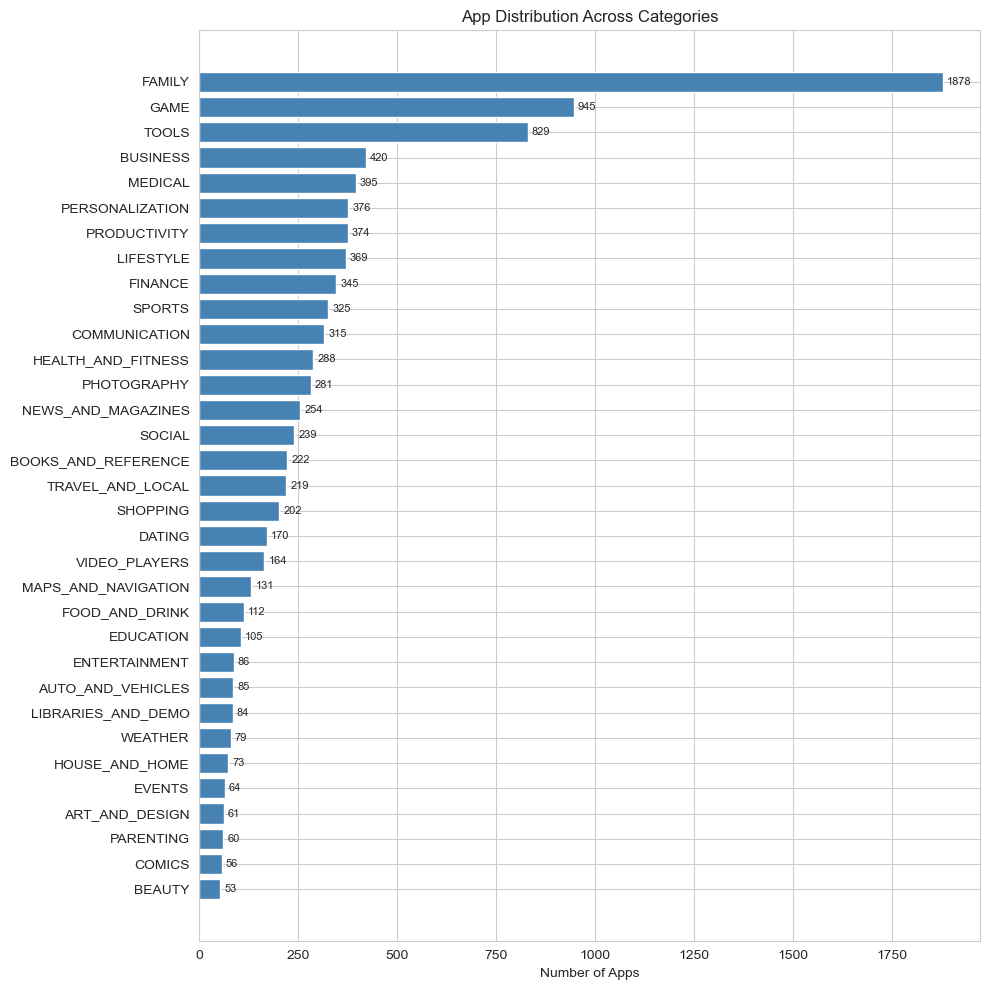

Category
FAMILY             1878
GAME                945
TOOLS               829
BUSINESS            420
MEDICAL             395
PERSONALIZATION     376
PRODUCTIVITY        374
LIFESTYLE           369
FINANCE             345
SPORTS              325
Name: count, dtype: int64


In [9]:
#Category analysis — distribution + saturation

category_counts = apps_df['Category'].value_counts()

plt.figure(figsize=(10, 10))
bars = plt.barh(category_counts.index[::-1], category_counts.values[::-1], color='steelblue')
plt.bar_label(bars, padding=3, fontsize=8)
plt.title("App Distribution Across Categories")
plt.xlabel("Number of Apps")
plt.tight_layout()
plt.show()

print(category_counts.head(10))

Category Saturation: FAMILY (1,878 apps) and GAME (945 apps) are by far the most saturated categories, together representing nearly 30% of all apps in the store. This makes them the most competitive markets for a new developer to enter — a new app would need to stand out against thousands of existing competitors. In contrast, categories like BEAUTY (53), COMICS (56), PARENTING (60), and ART_AND_DESIGN (61) have the fewest apps, potentially representing less crowded niches — though low app count alone doesn't confirm opportunity, since it could also reflect genuinely low user demand rather than an underserved market. The ratings and installs analysis in the next sections will help distinguish "underserved" from "unwanted."

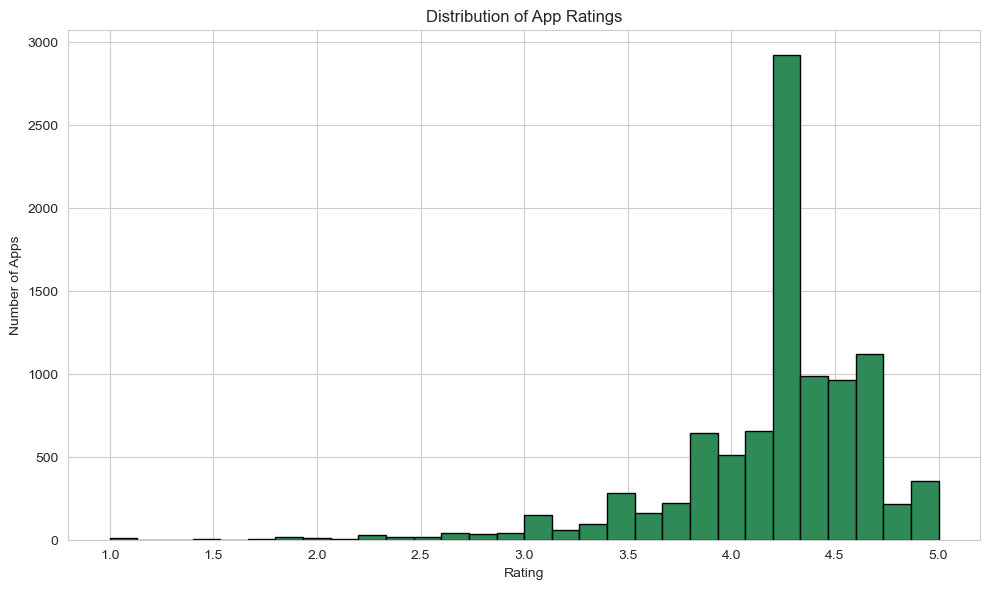

count    9659.000000
mean        4.189523
std         0.496703
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64


In [10]:
# Overall rating distribution
plt.figure(figsize=(10,6))
plt.hist(apps_df['Rating'], bins=30, color='seagreen', edgecolor='black')
plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.tight_layout()
plt.show()

print(apps_df['Rating'].describe())

Ratings Distribution: App ratings are heavily left-skewed — the overwhelming majority of apps sit between 4.0 and 4.8, with a sharp peak around 4.2-4.4 (nearly 3,000 apps in that single bin), and very few apps below 3.0. The mean rating (4.19) is actually lower than the median (4.3), confirming this skew — a small number of very poorly rated apps are pulling the average down, while most apps cluster tightly in the "good to great" range. This suggests that on the Play Store, a rating below ~4.0 is a genuine outlier/warning sign rather than an "average" app, and any new app should be targeting 4.3+ to be competitive with the norm rather than just "above average" in a loose sense.

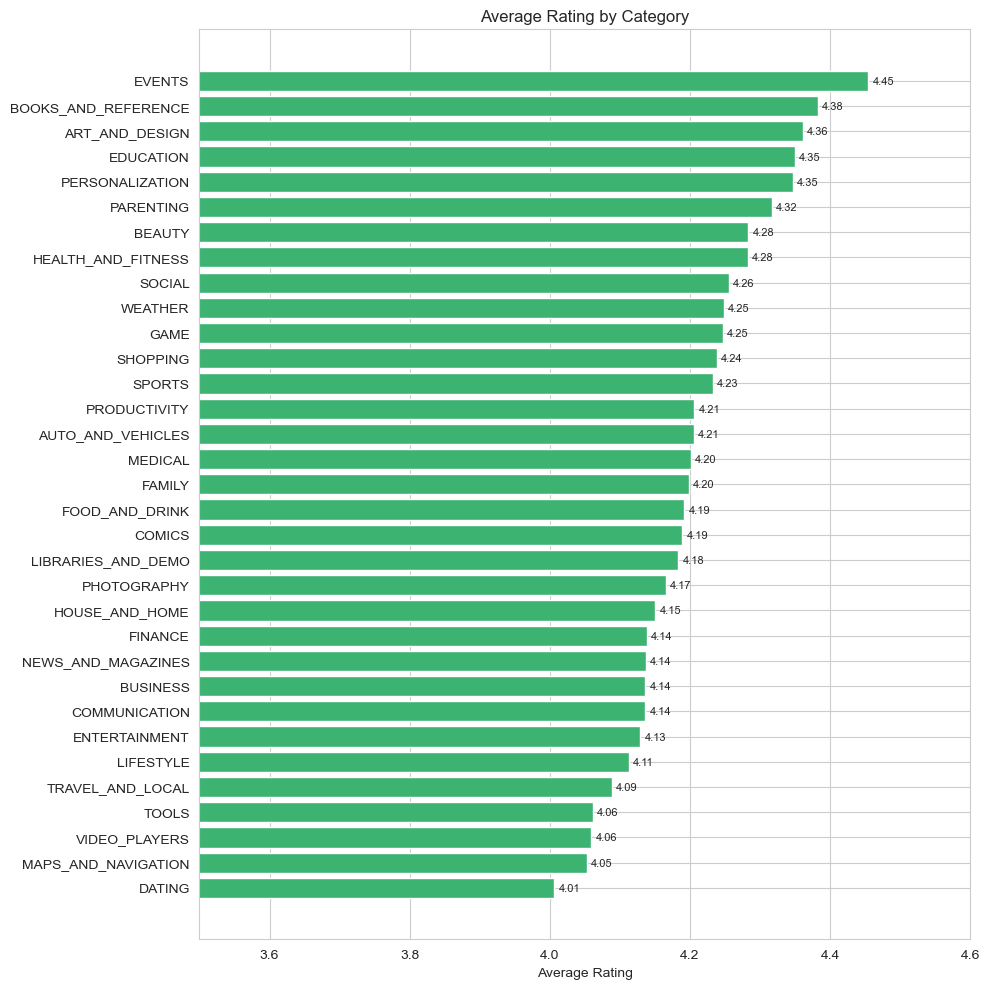

Category
EVENTS                 4.454688
BOOKS_AND_REFERENCE    4.381982
ART_AND_DESIGN         4.360656
EDUCATION              4.349524
PERSONALIZATION        4.346277
PARENTING              4.316667
BEAUTY                 4.283019
HEALTH_AND_FITNESS     4.282292
SOCIAL                 4.255230
WEATHER                4.248101
GAME                   4.247196
SHOPPING               4.238119
SPORTS                 4.232923
PRODUCTIVITY           4.206150
AUTO_AND_VEHICLES      4.205882
MEDICAL                4.201519
FAMILY                 4.198030
FOOD_AND_DRINK         4.191964
COMICS                 4.189286
LIBRARIES_AND_DEMO     4.183333
PHOTOGRAPHY            4.165125
HOUSE_AND_HOME         4.150685
FINANCE                4.138551
NEWS_AND_MAGAZINES     4.137008
BUSINESS               4.136429
COMMUNICATION          4.136190
ENTERTAINMENT          4.129070
LIFESTYLE              4.113008
TRAVEL_AND_LOCAL       4.088584
TOOLS                  4.061279
VIDEO_PLAYERS          4.059146

In [11]:
# Average rating by category
avg_rating_by_cat = apps_df.groupby('Category')['Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,10))
bars = plt.barh(avg_rating_by_cat.index[::-1], avg_rating_by_cat.values[::-1], color='mediumseagreen')
plt.bar_label(bars, fmt='%.2f', padding=3, fontsize=8)
plt.title("Average Rating by Category")
plt.xlabel("Average Rating")
plt.xlim(3.5, 4.6)  # zoomed in, since all category averages cluster in a narrow range
plt.tight_layout()
plt.show()

print(avg_rating_by_cat)

Average Rating by Category: EVENTS (4.45), BOOKS_AND_REFERENCE (4.38), and ART_AND_DESIGN (4.36) have the highest average ratings, while DATING (4.01), MAPS_AND_NAVIGATION (4.05), and VIDEO_PLAYERS (4.06) have the lowest. The DATING result is particularly notable when combined with the earlier category-saturation chart: DATING had a moderate app count (170 apps, mid-tier saturation) but the single lowest average rating of any category — suggesting a quality gap rather than a demand gap. This is a genuinely useful signal for a prospective developer: unlike a purely "underserved" category (few apps, unclear demand), DATING shows there's clear demand (170 existing apps trying to serve it) but consistent user dissatisfaction with existing options — a stronger opportunity signal than simply picking a low-competition category, since it points to a specific, addressable problem (existing apps in this space aren't meeting user expectations) rather than an unproven market.

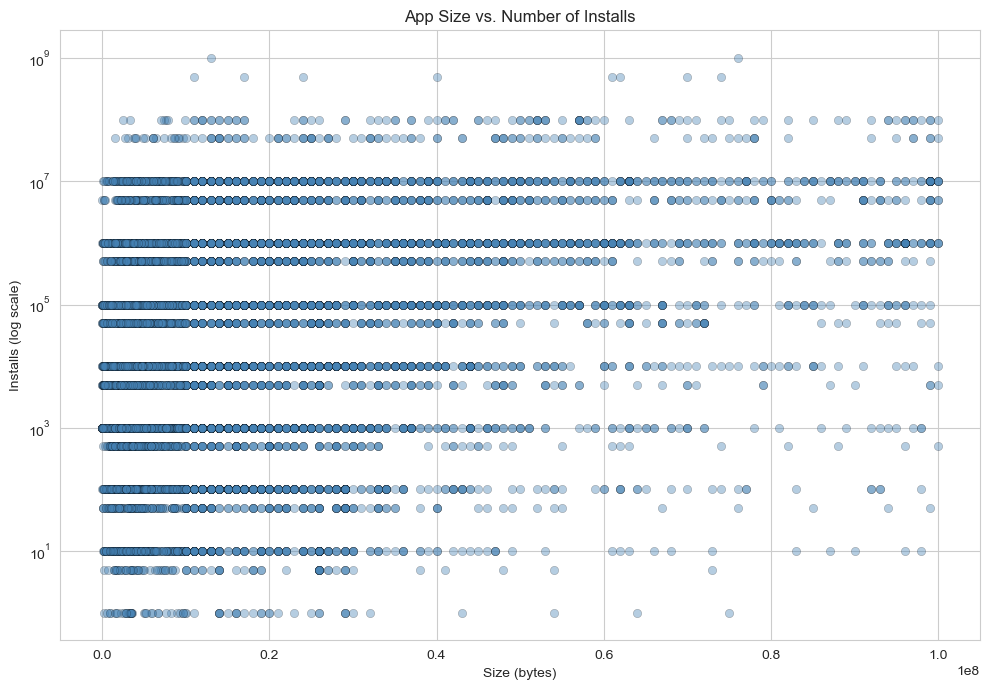

Correlation between Size and Installs: 0.1342


In [12]:
#Size vs. Installs — scatter plot + correlation

plt.figure(figsize=(10,7))
plt.scatter(apps_df['Size'], apps_df['Installs'], alpha=0.4, color='steelblue', edgecolor='k', linewidth=0.3)
plt.yscale('log')  # installs span many orders of magnitude (1 to 1 billion)
plt.title("App Size vs. Number of Installs")
plt.xlabel("Size (bytes)")
plt.ylabel("Installs (log scale)")
plt.tight_layout()
plt.show()

# Correlation (only on rows where Size isn't null)
size_installs_corr = apps_df[['Size', 'Installs']].corr().iloc[0,1]
print(f"Correlation between Size and Installs: {size_installs_corr:.4f}")

Size vs. Installs: The correlation between app size and number of installs is very weak (r = 0.13), indicating app size has almost no predictive relationship with install count. The scatter plot shows apps of nearly every size — from a few KB to 100MB+ — achieving both very low and very high install counts, with no visible trend. This is a useful, somewhat counter-intuitive finding for a developer: making an app smaller (often assumed to improve download conversion, especially in markets with limited storage/data) does not, on its own, correlate with higher installs in this dataset. Install count appears to be driven by other factors — app quality, marketing, category, or ratings — rather than file size.

Type
Free    8905
Paid     754
Name: count, dtype: int64
Type
Free    92.19
Paid     7.81
Name: count, dtype: float64


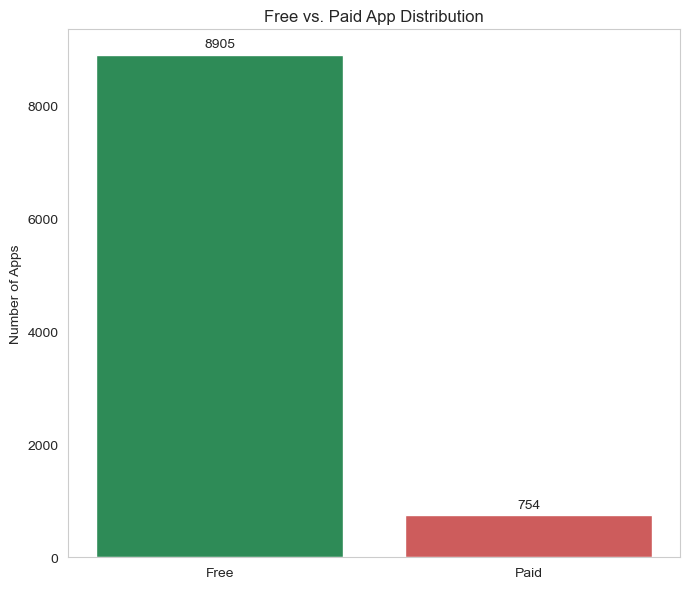

In [13]:
#Pricing analysis

# Free vs. Paid distribution
type_counts = apps_df['Type'].value_counts()
print(type_counts)
print((type_counts / type_counts.sum() * 100).round(2))

plt.figure(figsize=(7,6))
bars = plt.bar(type_counts.index, type_counts.values, color=['seagreen','indianred'])
plt.bar_label(bars, padding=3)
plt.title("Free vs. Paid App Distribution")
plt.ylabel("Number of Apps")
plt.grid(False)
plt.tight_layout()
plt.show()

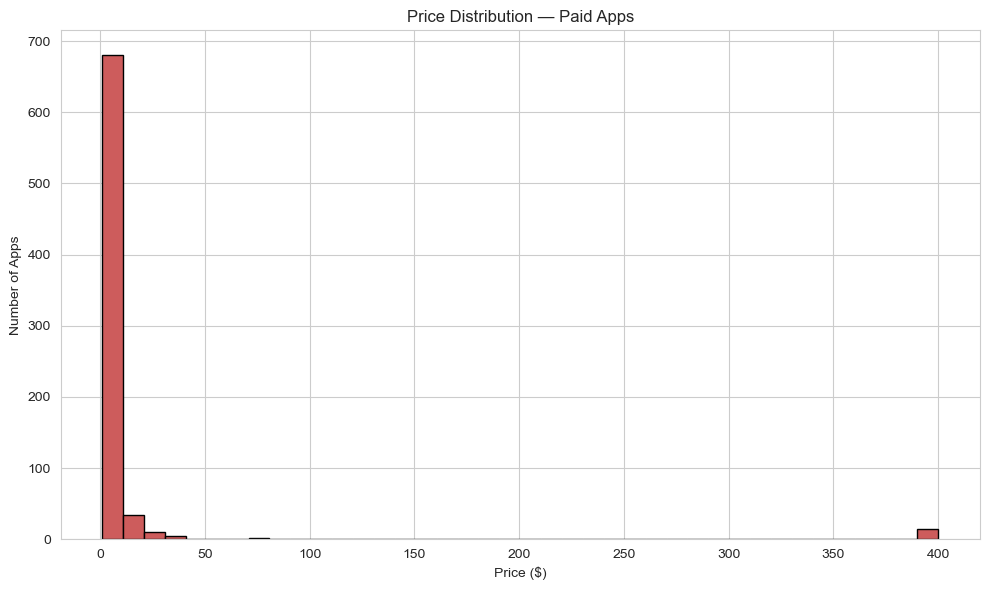

count    754.000000
mean      14.055902
std       58.821000
min        0.990000
25%        1.490000
50%        2.990000
75%        4.990000
max      400.000000
Name: Price, dtype: float64


In [14]:
# Price distribution for paid apps only
paid_apps = apps_df[apps_df['Type'] == 'Paid']

plt.figure(figsize=(10,6))
plt.hist(paid_apps['Price'], bins=40, color='indianred', edgecolor='black')
plt.title("Price Distribution — Paid Apps")
plt.xlabel("Price ($)")
plt.ylabel("Number of Apps")
plt.tight_layout()
plt.show()

print(paid_apps['Price'].describe())

Pricing Analysis: Only 7.81% of apps (754 of 9,659) are paid, confirming the Play Store's dominant free-to-download model — with the implication that even "paid" apps typically rely on volume or in-app purchases/ads rather than a large paid customer base. Among paid apps, pricing is heavily right-skewed: the median price is $2.99, but the mean ($14.06) is pulled far higher by a small cluster of apps priced at exactly $400 — most likely novelty "joke" apps rather than genuinely premium products, and worth excluding as outliers if a developer were using this data to benchmark realistic pricing. The bulk of real paid apps cluster between $0.99 and $4.99, suggesting this is the realistic, competitive price range for a new paid app.

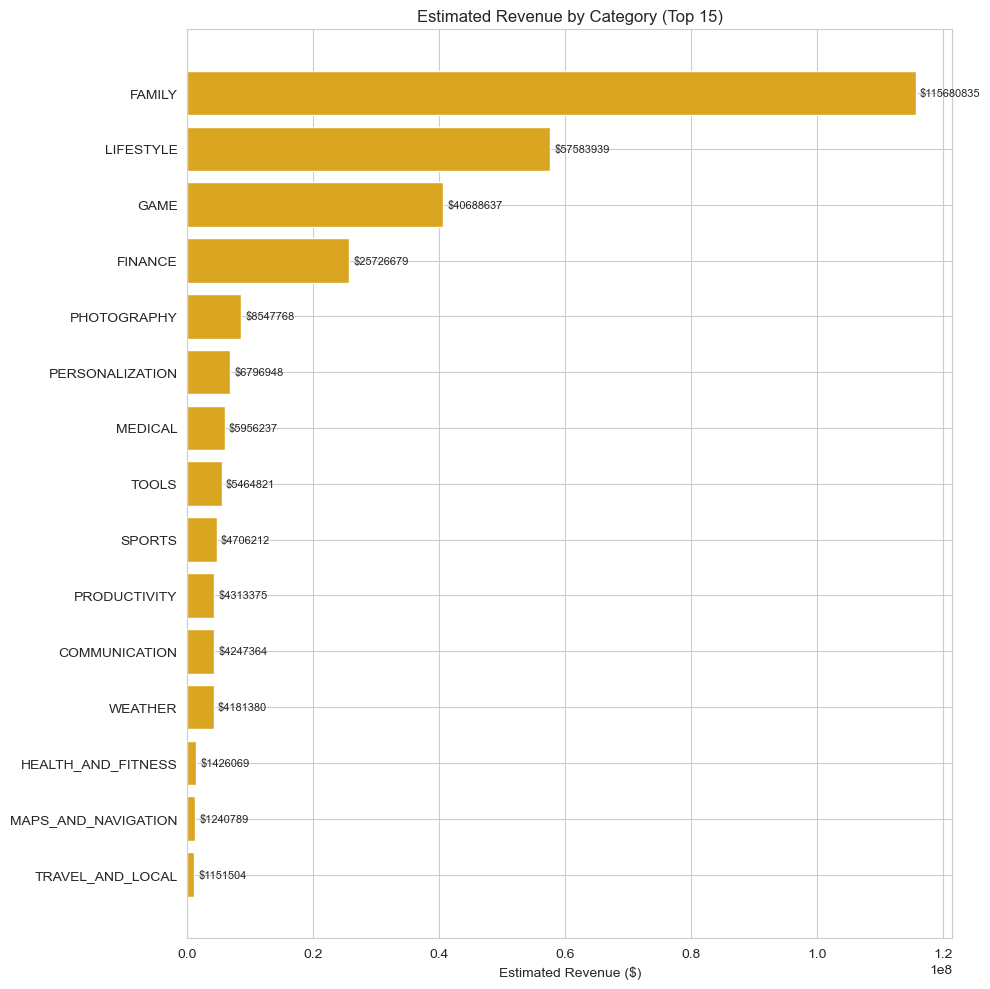

Category
FAMILY                 1.156808e+08
LIFESTYLE              5.758394e+07
GAME                   4.068864e+07
FINANCE                2.572668e+07
PHOTOGRAPHY            8.547768e+06
PERSONALIZATION        6.796948e+06
MEDICAL                5.956237e+06
TOOLS                  5.464821e+06
SPORTS                 4.706212e+06
PRODUCTIVITY           4.313375e+06
COMMUNICATION          4.247364e+06
WEATHER                4.181380e+06
HEALTH_AND_FITNESS     1.426069e+06
MAPS_AND_NAVIGATION    1.240789e+06
TRAVEL_AND_LOCAL       1.151504e+06
Name: Estimated_Revenue, dtype: float64


In [15]:
# Revenue estimate by category: Price * Installs (rough proxy — installs isn't exact purchase count, but best available signal)
apps_df['Estimated_Revenue'] = apps_df['Price'] * apps_df['Installs']
revenue_by_category = apps_df.groupby('Category')['Estimated_Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,10))
bars = plt.barh(revenue_by_category.head(15).index[::-1], revenue_by_category.head(15).values[::-1], color='goldenrod')
plt.bar_label(bars, fmt='$%.0f', padding=3, fontsize=8)
plt.title("Estimated Revenue by Category (Top 15)")
plt.xlabel("Estimated Revenue ($)")
plt.tight_layout()
plt.show()

print(revenue_by_category.head(15))

Revenue by Category: FAMILY generates by far the highest estimated revenue among paid apps, followed by LIFESTYLE, GAME, and FINANCE. This is a useful complement to the earlier "most saturated" finding — FAMILY is both the most saturated category (1,878 apps) and the highest-revenue category, meaning the competition there is intense but so is the proven monetary opportunity. This is a genuinely important distinction for a developer: a saturated category isn't automatically a bad choice if it's also where the money demonstrably is — the risk is competition, not lack of demand.

In [18]:
!pip install textblob

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 1.5 MB/s  0:00:00


In [19]:
#Sentiment analysis on reviews

from textblob import TextBlob

def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0.05:
        return 'Positive'
    elif polarity < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

reviews_df['My_Sentiment'] = reviews_df['Translated_Review'].apply(get_sentiment)

print(reviews_df['My_Sentiment'].value_counts())
print()
# Compare against the dataset's pre-existing sentiment labels, as a validity check
print("Agreement with pre-existing labels:")
print((reviews_df['My_Sentiment'] == reviews_df['Sentiment']).mean())

My_Sentiment
Positive    17873
Neutral      6443
Negative     5376
Name: count, dtype: int64

Agreement with pre-existing labels:
0.9297117068570658


Sentiment Classification Results: TextBlob classified 17,873 reviews (60.2%) as Positive, 6,443 (21.7%) as Neutral, and 5,376 (18.1%) as Negative — an overall favorable skew, consistent with the earlier finding that most apps carry high star ratings (median 4.3). Our independent classification agreed with the dataset's pre-existing sentiment labels 93.0% of the time, validating that the polarity-threshold approach used here produces results consistent with established sentiment labeling methodology. The ~7% disagreement is expected and reasonable — sentiment classification inherently involves some subjectivity at the boundary between "weakly positive/negative" and "neutral," which is exactly where polarity-threshold methods are most likely to diverge from other labeling approaches.

In [20]:
# Merge reviews with app categories
reviews_with_category = reviews_df.merge(apps_df[['App', 'Category']], on='App', how='left')

print("Reviews before merge:", reviews_df.shape[0])
print("Reviews after merge:", reviews_with_category.shape[0])
print("Reviews with no matching category (app not in apps_df):", reviews_with_category['Category'].isnull().sum())

# Drop reviews for apps we couldn't match to a category
reviews_with_category = reviews_with_category.dropna(subset=['Category'])

Reviews before merge: 29692
Reviews after merge: 29692
Reviews with no matching category (app not in apps_df): 1442


<Figure size 1100x1000 with 0 Axes>

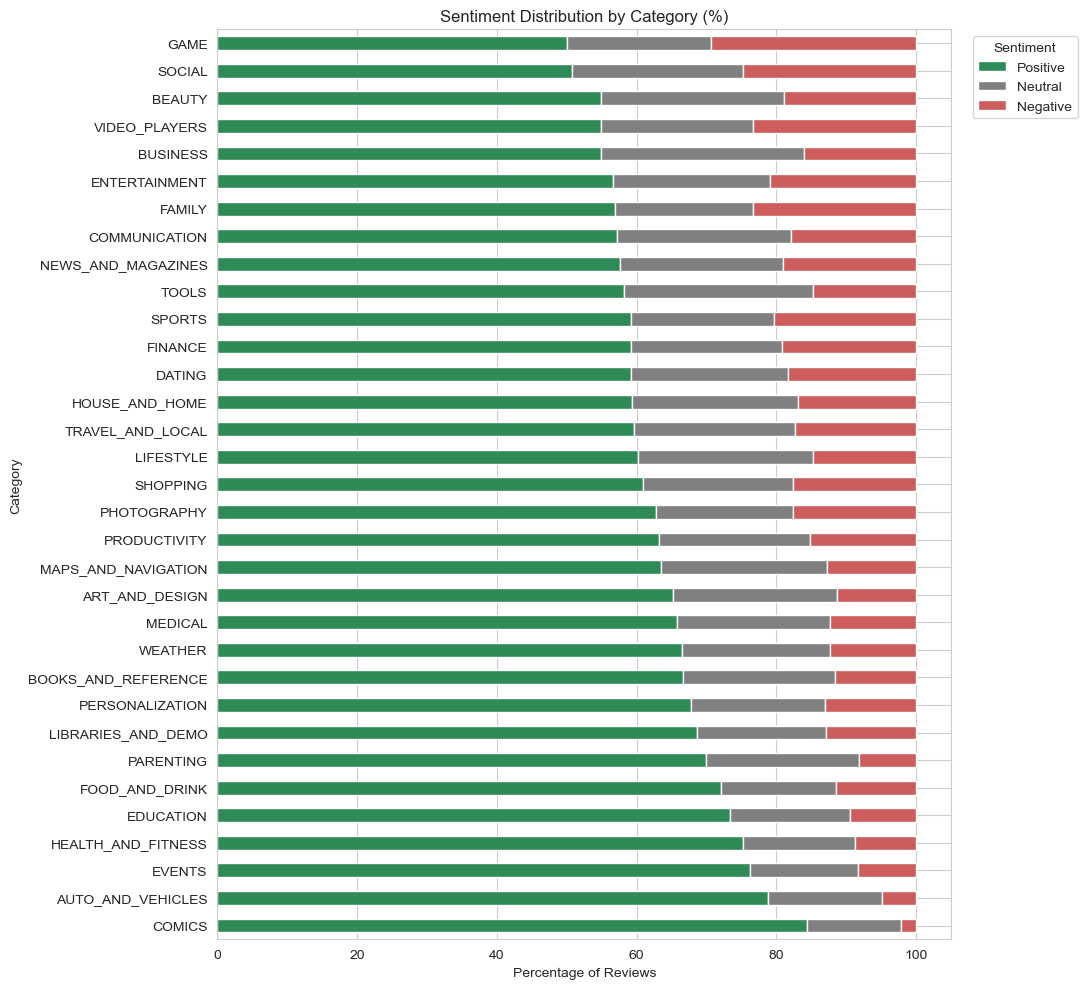

My_Sentiment          Negative    Neutral   Positive
Category                                            
COMICS                2.222222  13.333333  84.444444
AUTO_AND_VEHICLES     4.946996  16.254417  78.798587
EVENTS                8.333333  15.384615  76.282051
HEALTH_AND_FITNESS    8.698334  16.101172  75.200494
EDUCATION             9.441233  17.148362  73.410405
FOOD_AND_DRINK       11.492281  16.466552  72.041166
PARENTING             8.203125  21.875000  69.921875
LIBRARIES_AND_DEMO   12.951807  18.373494  68.674699
PERSONALIZATION      13.007284  19.146722  67.845994
BOOKS_AND_REFERENCE  11.669368  21.717990  66.612642

My_Sentiment         Negative    Neutral   Positive
Category                                           
GAME                29.354756  20.606988  50.038256
SOCIAL              24.810893  24.508321  50.680787
FAMILY              23.397436  19.751603  56.850962
VIDEO_PLAYERS       23.312883  21.779141  54.907975
ENTERTAINMENT       20.970043  22.396576  56.633381

In [21]:
# Sentiment distribution by category (as % within each category, for fair comparison)
sentiment_by_category = pd.crosstab(reviews_with_category['Category'], reviews_with_category['My_Sentiment'], normalize='index') * 100

# Sort by % Positive for a clean, readable chart
sentiment_by_category = sentiment_by_category.sort_values('Positive', ascending=False)

plt.figure(figsize=(11, 10))
sentiment_by_category[['Positive', 'Neutral', 'Negative']].plot(
    kind='barh', stacked=True, color=['seagreen', 'gray', 'indianred'], figsize=(11,10)
)
plt.title("Sentiment Distribution by Category (%)")
plt.xlabel("Percentage of Reviews")
plt.legend(title='Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(sentiment_by_category.sort_values('Positive', ascending=False).head(10))
print()
print(sentiment_by_category.sort_values('Negative', ascending=False).head(10))

Sentiment by Category: COMICS (84.4% positive), AUTO_AND_VEHICLES (78.8%), and EVENTS (76.3%) have the most positive review sentiment, while GAME has the highest negative sentiment share of any category (29.4%) — despite GAME being the second-most saturated category by app count (945 apps) with a respectable average star rating (4.25, ranked 11th out of 33 in the earlier analysis). This is a genuinely interesting discrepancy: star ratings and review-text sentiment aren't perfectly aligned for GAME — a category where users may rate an app highly on the star scale (perhaps reflecting genuine addiction/engagement) while still writing negative reviews about specific frustrations (bugs, ads, in-app purchase pressure, difficulty spikes). SOCIAL (24.8% negative) and FAMILY (23.4% negative) show a similar pattern.

Interestingly, DATING appears in the "most positive" review-sentiment tail here (59.2% positive), which stands in contrast to it having the lowest average star rating (4.01) of any category found earlier. This divergence between star ratings and review-text sentiment for DATING is worth flagging as a genuine, non-obvious finding — it may suggest that dissatisfied DATING users are more likely to leave a low star rating without writing detailed negative text, while satisfied users are more likely to write positive reviews (a common asymmetry in review behavior generally), meaning star rating and written sentiment may be capturing different aspects of user experience for this category.

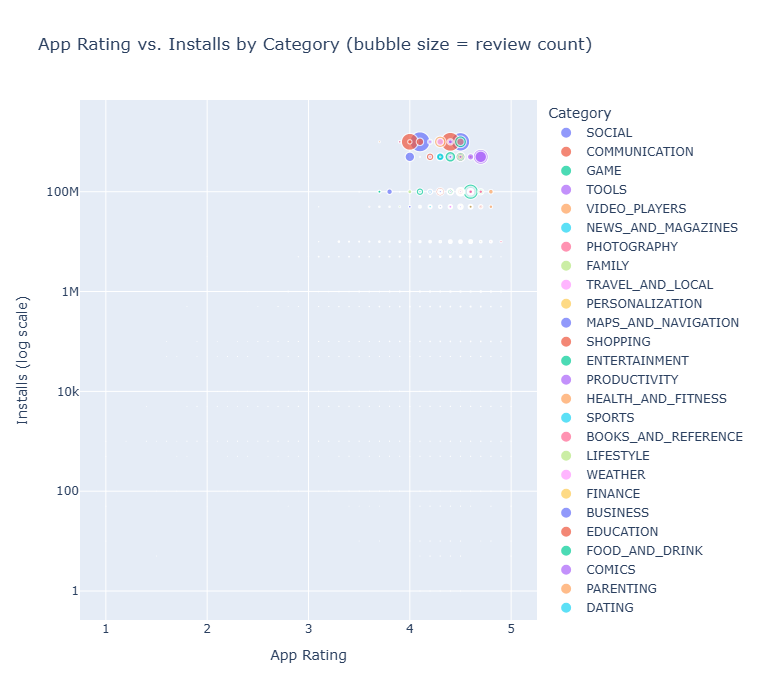

In [22]:
#Plotly interactive visualization (recommended bonus)

import plotly.express as px

# Interactive scatter: Rating vs. Installs vs. Category, sized by Reviews count
fig = px.scatter(
    apps_df,
    x='Rating',
    y='Installs',
    color='Category',
    size='Reviews',
    hover_name='App',
    log_y=True,
    title='App Rating vs. Installs by Category (bubble size = review count)',
    labels={'Installs': 'Installs (log scale)', 'Rating': 'App Rating'}
)
fig.update_layout(height=700)
fig.show()

Plotly Visualization: An interactive Plotly scatter plot was used to explore the relationship between rating, installs, and category simultaneously — something a static chart can't do well with this many dimensions. Hovering over any point reveals the specific app, and clicking a category in the legend isolates it for comparison, making this a genuinely more useful exploratory tool than the static matplotlib equivalents used elsewhere in this notebook.

## Conclusion: 3 Data-Driven Insights for a Developer Planning to Launch a New App

**1. Target DATING for a quality-driven entry — the market has demand but visible dissatisfaction.**
DATING has a moderate number of existing apps (170) but the *lowest* average star rating of any category (4.01), signaling users have real complaints with existing options rather than the category simply lacking demand. Interestingly, DATING also scored relatively well on review-text sentiment (59.2% positive) — suggesting the dissatisfaction shows up more in star ratings than in what users write, possibly reflecting frustration with things like the matching experience or trust/safety rather than app functionality itself. A new entrant with a clear differentiator (e.g. stronger safety features, a more curated matching approach) has a more evidence-backed opportunity here than in an "empty" category with no proven demand at all.

**2. Price in the $0.99–$4.99 range if going paid, and don't assume smaller app size drives more installs.**
92.2% of apps are free, and among the 7.8% that are paid, the real market clusters tightly between $0.99 and $4.99 (median $2.99) — pricing meaningfully above this range (excluding clear outlier/novelty apps) departs from where the vast majority of paid apps actually sit. Separately, app size showed essentially no correlation with install count (r = 0.13) — a new developer shouldn't assume shrinking the app's file size is, by itself, a meaningful lever for driving downloads; installs appear far more tied to app quality, category, and marketing than technical footprint.

**3. Star ratings and review sentiment don't always agree — watch both, especially in GAME.**
GAME has a respectable average star rating (4.25) but the highest negative review-sentiment share of any category (29.4%) — a mismatch suggesting users may rate generously while still voicing specific frustrations in writing (ads, monetization pressure, bugs). A developer entering GAME should treat the high star-rating norm with some caution and pay close attention to actual review text, not just the aggregate star average, when benchmarking what "success" looks like or where competitors are quietly falling short.